# Explore here

In [169]:
# Your code here


import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv"
dt = pd.read_csv(url, sep=';')
print(dt.head(100).to_string(index=False))


 age           job  marital           education default housing    loan   contact month day_of_week  duration  campaign  pdays  previous    poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y
  56     housemaid  married            basic.4y      no      no      no telephone   may         mon       261         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
  57      services  married         high.school unknown      no      no telephone   may         mon       149         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
  37      services  married         high.school      no     yes      no telephone   may         mon       226         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
  40        admin.  married            basic.6y      no      no      no telephone   may         mon       151   

In [170]:
dt.shape

(41188, 21)

In [171]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [172]:

duplicados = dt.duplicated()
print(f"Número de filas duplicadas: {duplicados.sum()}")


duplicated_rows = dt[duplicados]
print(duplicated_rows.head())


Número de filas duplicadas: 12
       age          job   marital            education default housing loan  \
1266    39  blue-collar   married             basic.6y      no      no   no   
12261   36      retired   married              unknown      no      no   no   
14234   27   technician    single  professional.course      no      no   no   
16956   47   technician  divorced          high.school      no     yes   no   
18465   32   technician    single  professional.course      no     yes   no   

         contact month day_of_week  ...  campaign  pdays  previous  \
1266   telephone   may         thu  ...         1    999         0   
12261  telephone   jul         thu  ...         1    999         0   
14234   cellular   jul         mon  ...         2    999         0   
16956   cellular   jul         thu  ...         3    999         0   
18465   cellular   jul         thu  ...         1    999         0   

          poutcome emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m

In [173]:
dt = dt.drop_duplicates()


Borra los datos duplicados 

In [174]:

valores_nulos = dt.isnull().sum()


print(valores_nulos[valores_nulos > 0])


Series([], dtype: int64)


In [175]:
dt.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

variables a borrar, marital, education, contact,month,day_of_week,duration,campaign,pdays,

In [176]:
cols_to_drop = [
    'marital', 'education', 'contact', 'month',
    'day_of_week', 'duration', 'campaign', 'pdays'
]
dt = dt.drop(columns=cols_to_drop)


In [177]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   default         41176 non-null  object 
 3   housing         41176 non-null  object 
 4   loan            41176 non-null  object 
 5   previous        41176 non-null  int64  
 6   poutcome        41176 non-null  object 
 7   emp.var.rate    41176 non-null  float64
 8   cons.price.idx  41176 non-null  float64
 9   cons.conf.idx   41176 non-null  float64
 10  euribor3m       41176 non-null  float64
 11  nr.employed     41176 non-null  float64
 12  y               41176 non-null  object 
dtypes: float64(5), int64(2), object(6)
memory usage: 4.4+ MB


Variables Categoricas

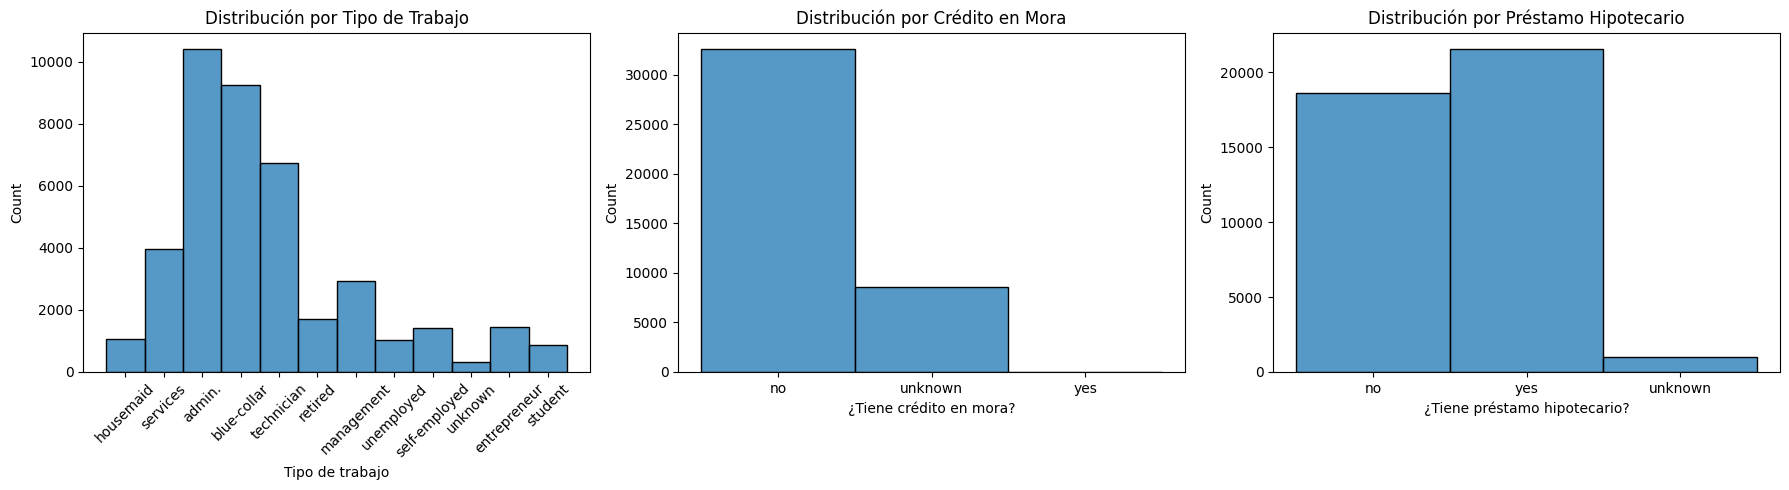

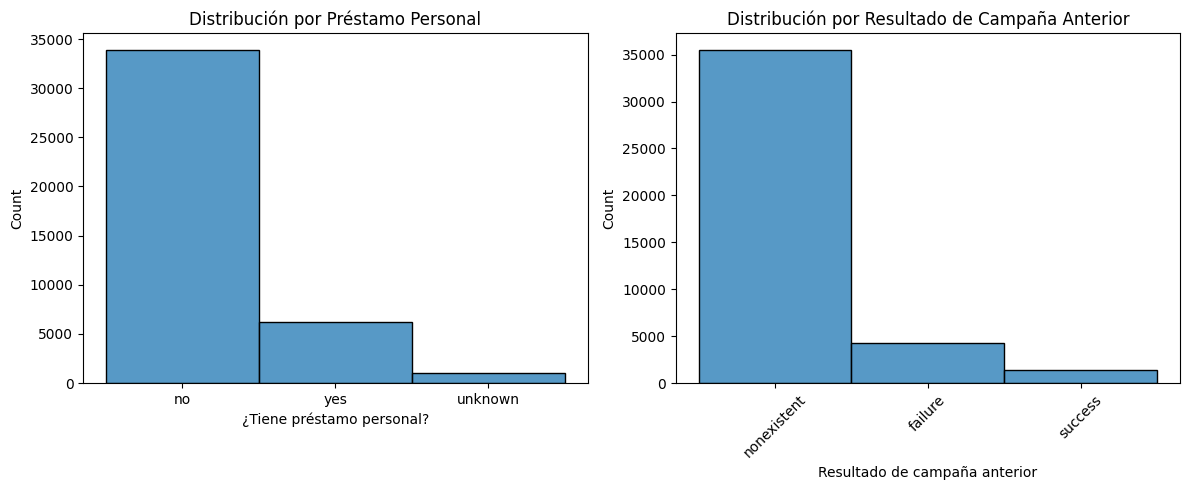

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axis = plt.subplots(1, 3, figsize=(18, 5))


sns.histplot(ax=axis[0], data=dt, x="job")
axis[0].set_title("Distribución por Tipo de Trabajo")
axis[0].set_xlabel("Tipo de trabajo")
axis[0].tick_params(axis='x', rotation=45)


sns.histplot(ax=axis[1], data=dt, x="default")
axis[1].set_title("Distribución por Crédito en Mora")
axis[1].set_xlabel("¿Tiene crédito en mora?")


sns.histplot(ax=axis[2], data=dt, x="housing")
axis[2].set_title("Distribución por Préstamo Hipotecario")
axis[2].set_xlabel("¿Tiene préstamo hipotecario?")

plt.tight_layout()
plt.show()


fig, axis = plt.subplots(1, 2, figsize=(12, 5))


sns.histplot(ax=axis[0], data=dt, x="loan")
axis[0].set_title("Distribución por Préstamo Personal")
axis[0].set_xlabel("¿Tiene préstamo personal?")


sns.histplot(ax=axis[1], data=dt, x="poutcome")
axis[1].set_title("Distribución por Resultado de Campaña Anterior")
axis[1].set_xlabel("Resultado de campaña anterior")
axis[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


El banco cuenta con una cantidad importante de trabajadores del sector administrativo y cuellos azul, muchos de sus clientes no tiene créditos en mora y cuenta con muchos clientes que tiene hipoteca. Con respecto a los préstamos personales muchos no tienen préstamos, el gráfico de campañas anteriores no tuvo mucho éxito

variables numéricas

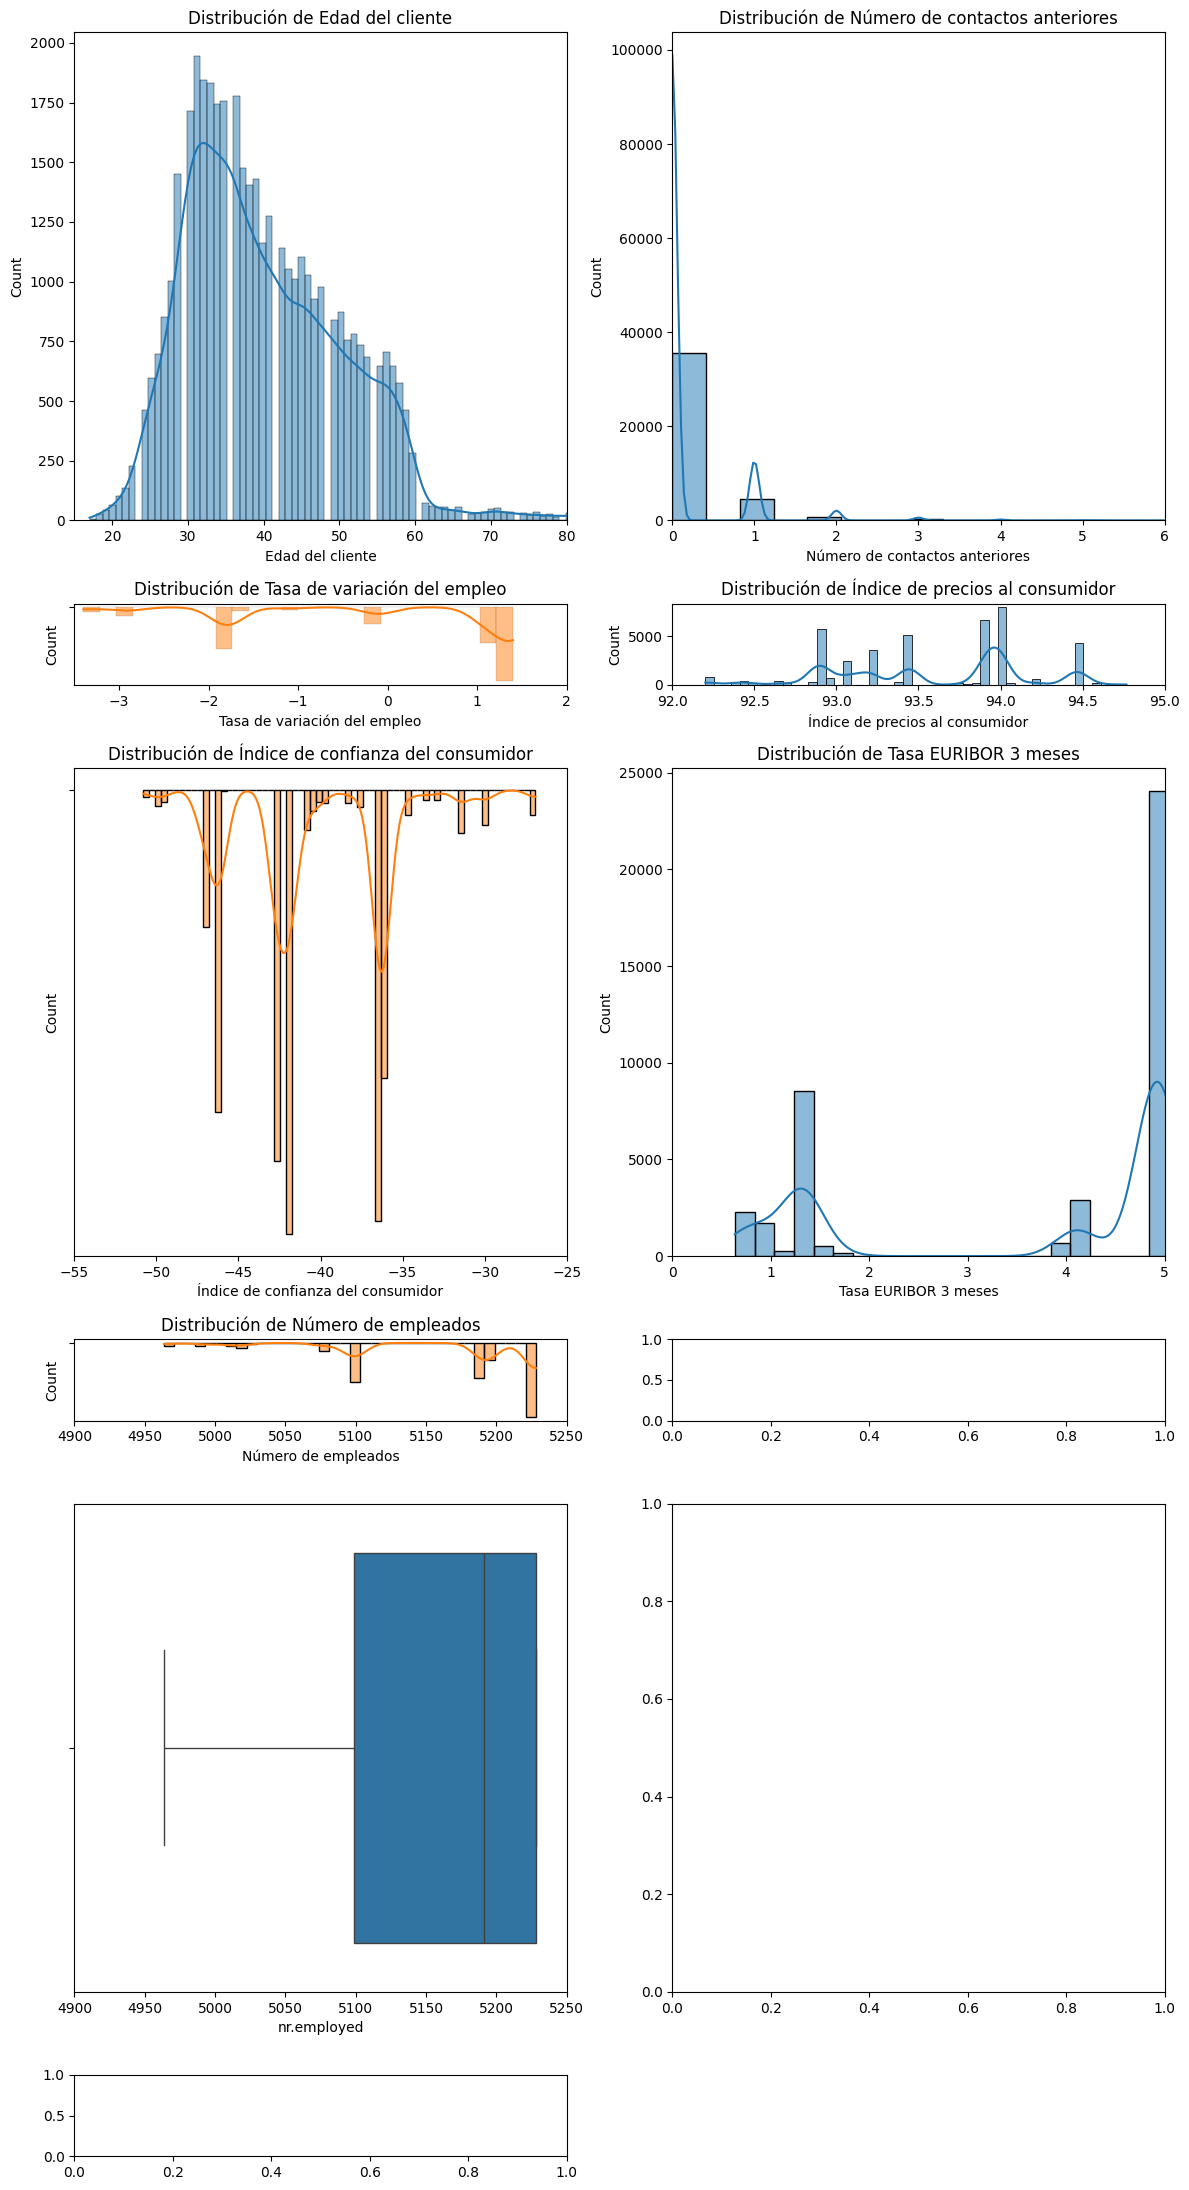

In [179]:
import matplotlib.pyplot as plt 
import seaborn as sns


fig, axis = plt.subplots(6, 2, figsize=(12, 22), gridspec_kw={"height_ratios": [6, 1, 6, 1, 6, 1]})

numerical_columns = ['age', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
                     'euribor3m', 'nr.employed']


column_names_es = {
    'age': 'Edad del cliente',
    'previous': 'Número de contactos anteriores',
    'emp.var.rate': 'Tasa de variación del empleo',
    'cons.price.idx': 'Índice de precios al consumidor',
    'cons.conf.idx': 'Índice de confianza del consumidor',
    'euribor3m': 'Tasa EURIBOR 3 meses',
    'nr.employed': 'Número de empleados'
}


xlimits = {
    'age': (15, 80),
    'previous': (0, 6),
    'emp.var.rate': (-3.5, 2),
    'cons.price.idx': (92, 95),
    'cons.conf.idx': (-55, -25),
    'euribor3m': (0, 5),
    'nr.employed': (4900, 5250)
}


for i, column in enumerate(numerical_columns):
    sns.histplot(ax=axis[i // 2, i % 2], data=dt, x=column, kde=True)
    axis[i // 2, i % 2].set_title(f"Distribución de {column_names_es[column]}")
    axis[i // 2, i % 2].set_xlabel(column_names_es[column])
    axis[i // 2, i % 2].set_xlim(xlimits[column])
    
    if i % 2 == 0:
        sns.boxplot(ax=axis[i // 2 + 1, i % 2], data=dt, x=column)
        axis[i // 2 + 1, i % 2].set_xlim(xlimits[column])

fig.delaxes(axis[5, 1])  
plt.tight_layout()
plt.show()


Los clientes del banco su mayoría se encuentran en un rango de edad entre los 25 y 45 años, y son clientes que anteriormente no se contactaron. 

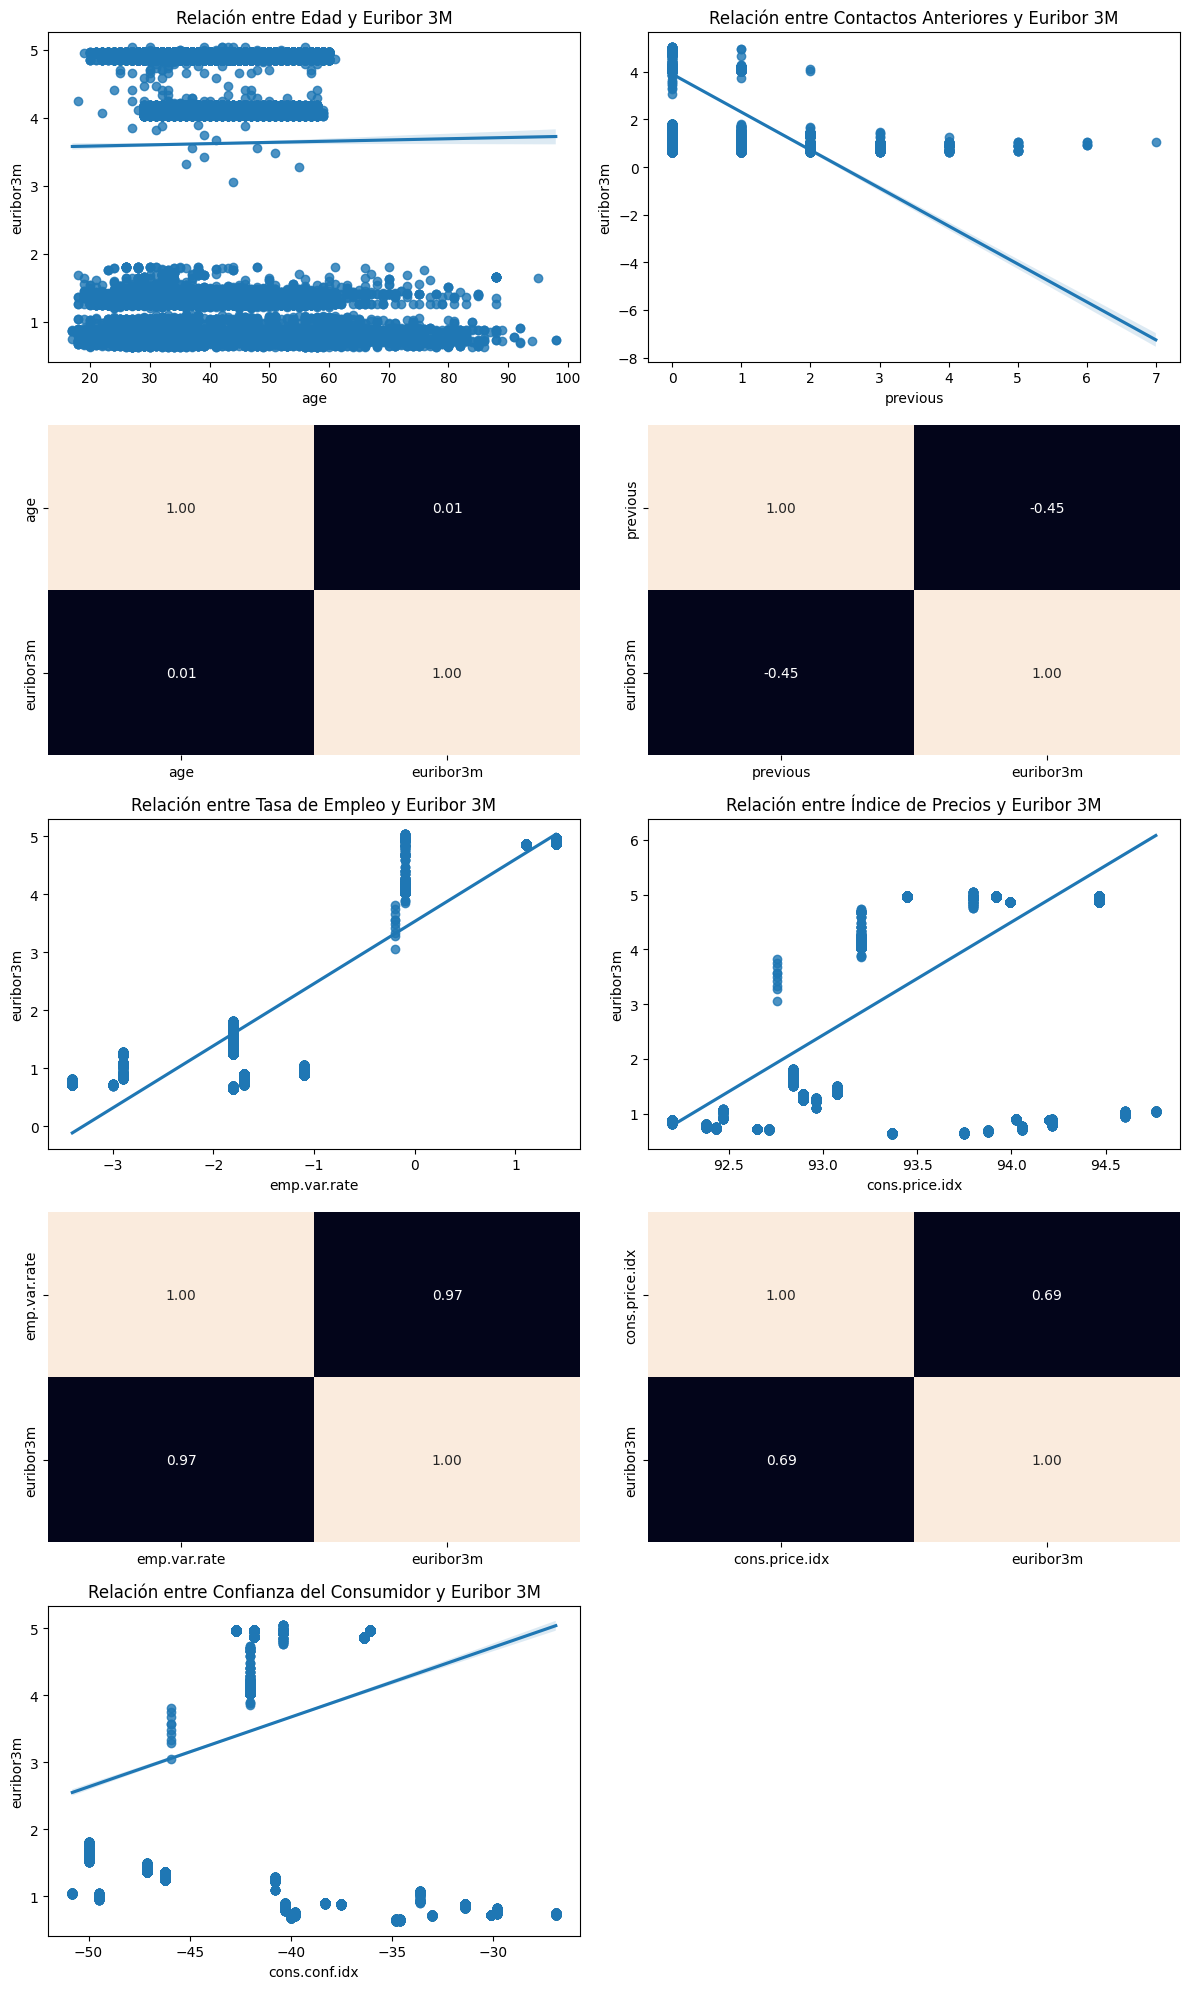

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(5, 2, figsize=(12, 20))  


sns.regplot(ax=axis[0, 0], data=dt, x="age", y="euribor3m")
axis[0, 0].set_title("Relación entre Edad y Euribor 3M")
sns.heatmap(dt[["age", "euribor3m"]].corr(), annot=True, fmt=".2f", ax=axis[1, 0], cbar=False)


sns.regplot(ax=axis[0, 1], data=dt, x="previous", y="euribor3m")
axis[0, 1].set_title("Relación entre Contactos Anteriores y Euribor 3M")
sns.heatmap(dt[["previous", "euribor3m"]].corr(), annot=True, fmt=".2f", ax=axis[1, 1], cbar=False)


sns.regplot(ax=axis[2, 0], data=dt, x="emp.var.rate", y="euribor3m")
axis[2, 0].set_title("Relación entre Tasa de Empleo y Euribor 3M")
sns.heatmap(dt[["emp.var.rate", "euribor3m"]].corr(), annot=True, fmt=".2f", ax=axis[3, 0], cbar=False)


sns.regplot(ax=axis[2, 1], data=dt, x="cons.price.idx", y="euribor3m")
axis[2, 1].set_title("Relación entre Índice de Precios y Euribor 3M")
sns.heatmap(dt[["cons.price.idx", "euribor3m"]].corr(), annot=True, fmt=".2f", ax=axis[3, 1], cbar=False)


sns.regplot(ax=axis[4, 0], data=dt, x="cons.conf.idx", y="euribor3m")
axis[4, 0].set_title("Relación entre Confianza del Consumidor y Euribor 3M")


fig.delaxes(axis[4, 1])

plt.tight_layout()
plt.show()


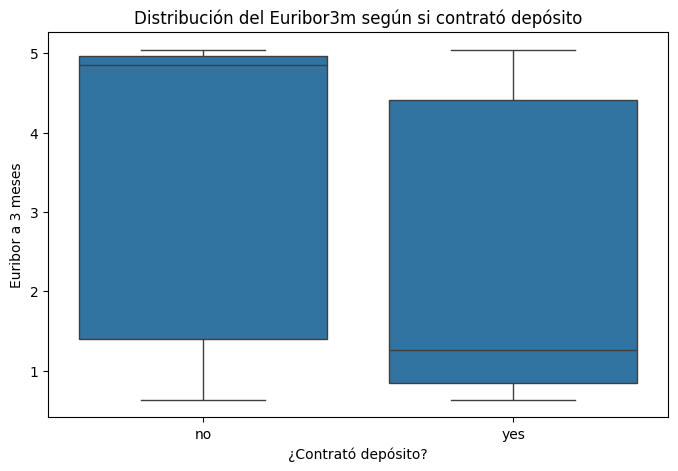

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=dt, x='y', y='euribor3m')
plt.title('Distribución del Euribor3m según si contrató depósito')
plt.xlabel('¿Contrató depósito?')
plt.ylabel('Euribor a 3 meses')
plt.show()


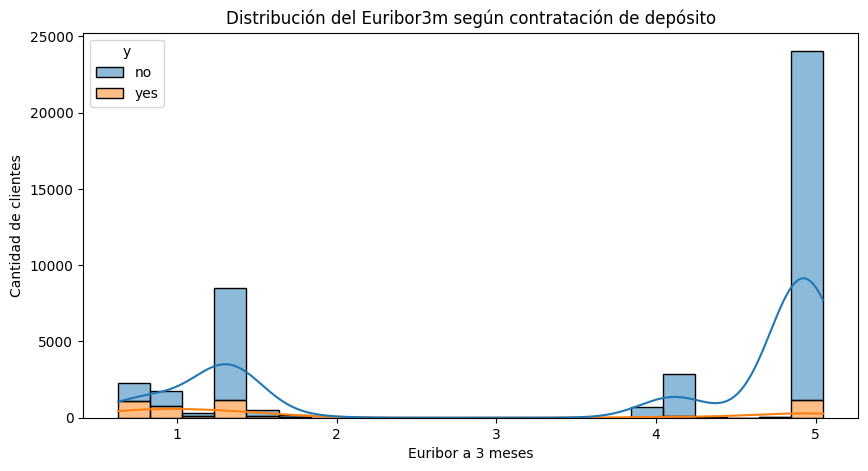

In [182]:
plt.figure(figsize=(10, 5))
sns.histplot(data=dt, x='euribor3m', hue='y', kde=True, multiple='stack')
plt.title('Distribución del Euribor3m según contratación de depósito')
plt.xlabel('Euribor a 3 meses')
plt.ylabel('Cantidad de clientes')
plt.show()


Mientras mas alto este el euribor3m (es una tasa de interés de referencia muy usada en Europa)menos se contratan los depositos a largo plazo 

Análisis categórico-categórico


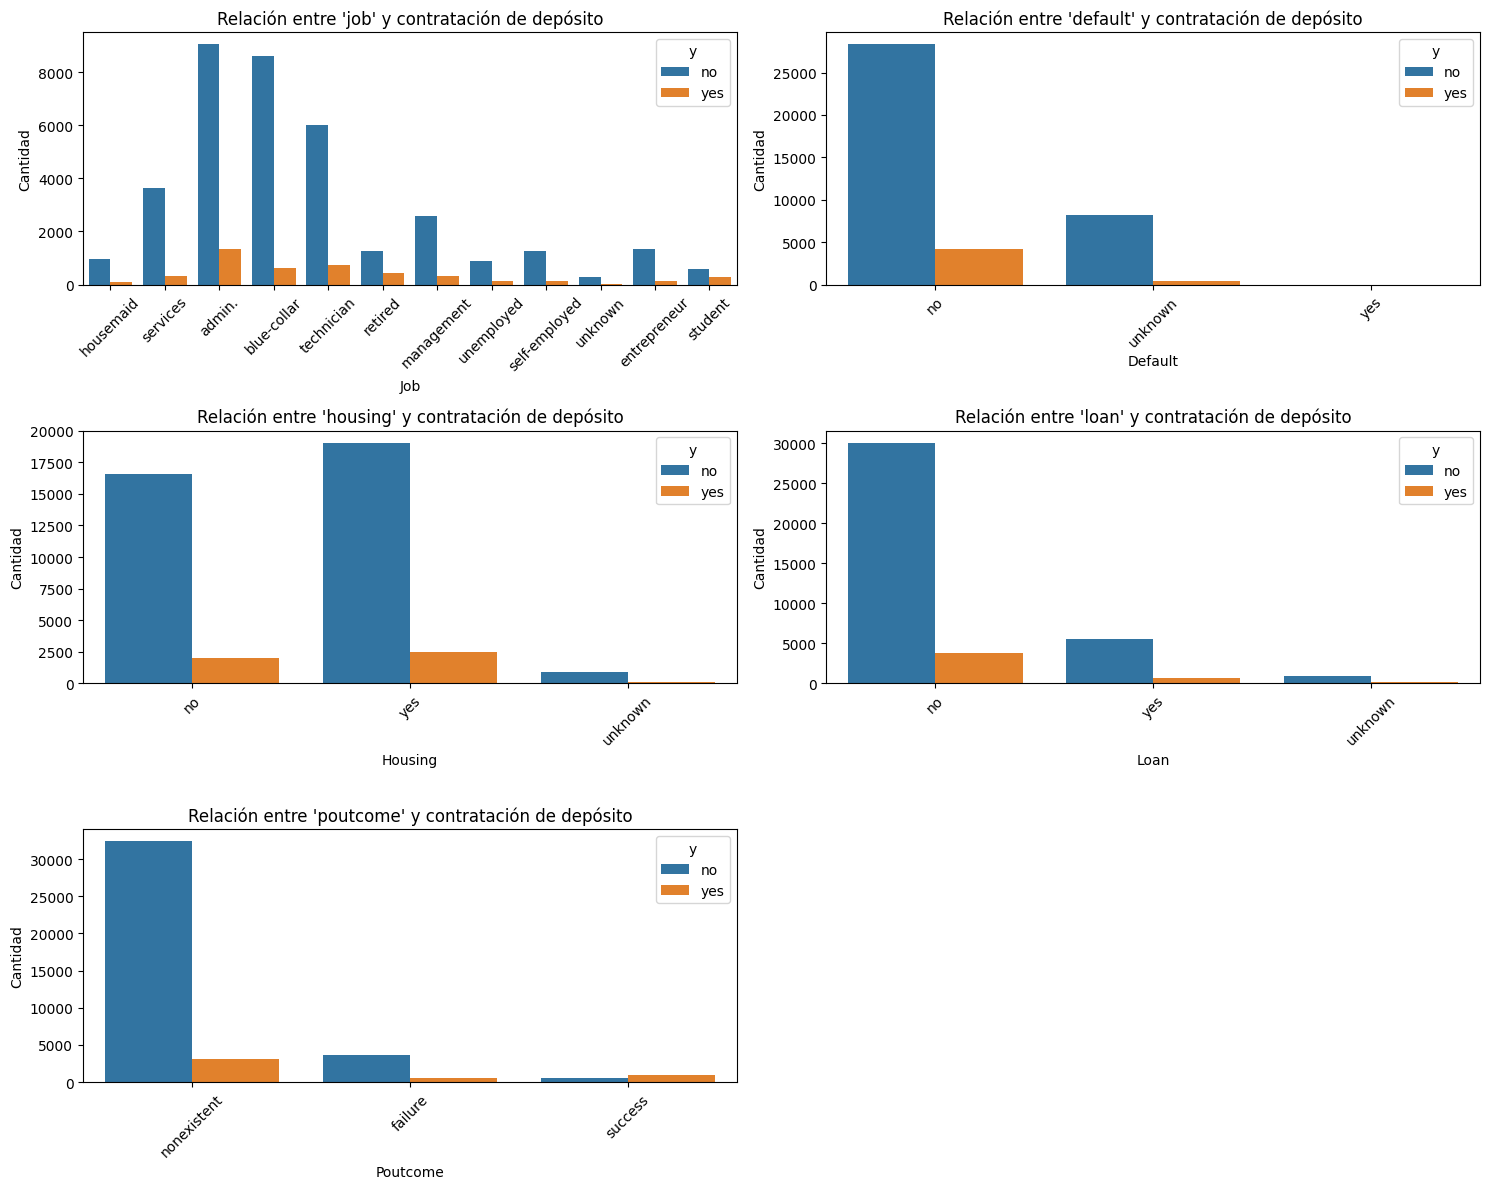

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_columns = ["job", "default", "housing", "loan", "poutcome"]
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))

for i, col in enumerate(categorical_columns):
    ax = axes[i // 2, i % 2]
    sns.countplot(x=col, hue="y", data=dt, ax=ax)
    ax.set_title(f"Relación entre '{col}' y contratación de depósito")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis='x', rotation=45)


fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()


Análisis numérico-categórico (completo)


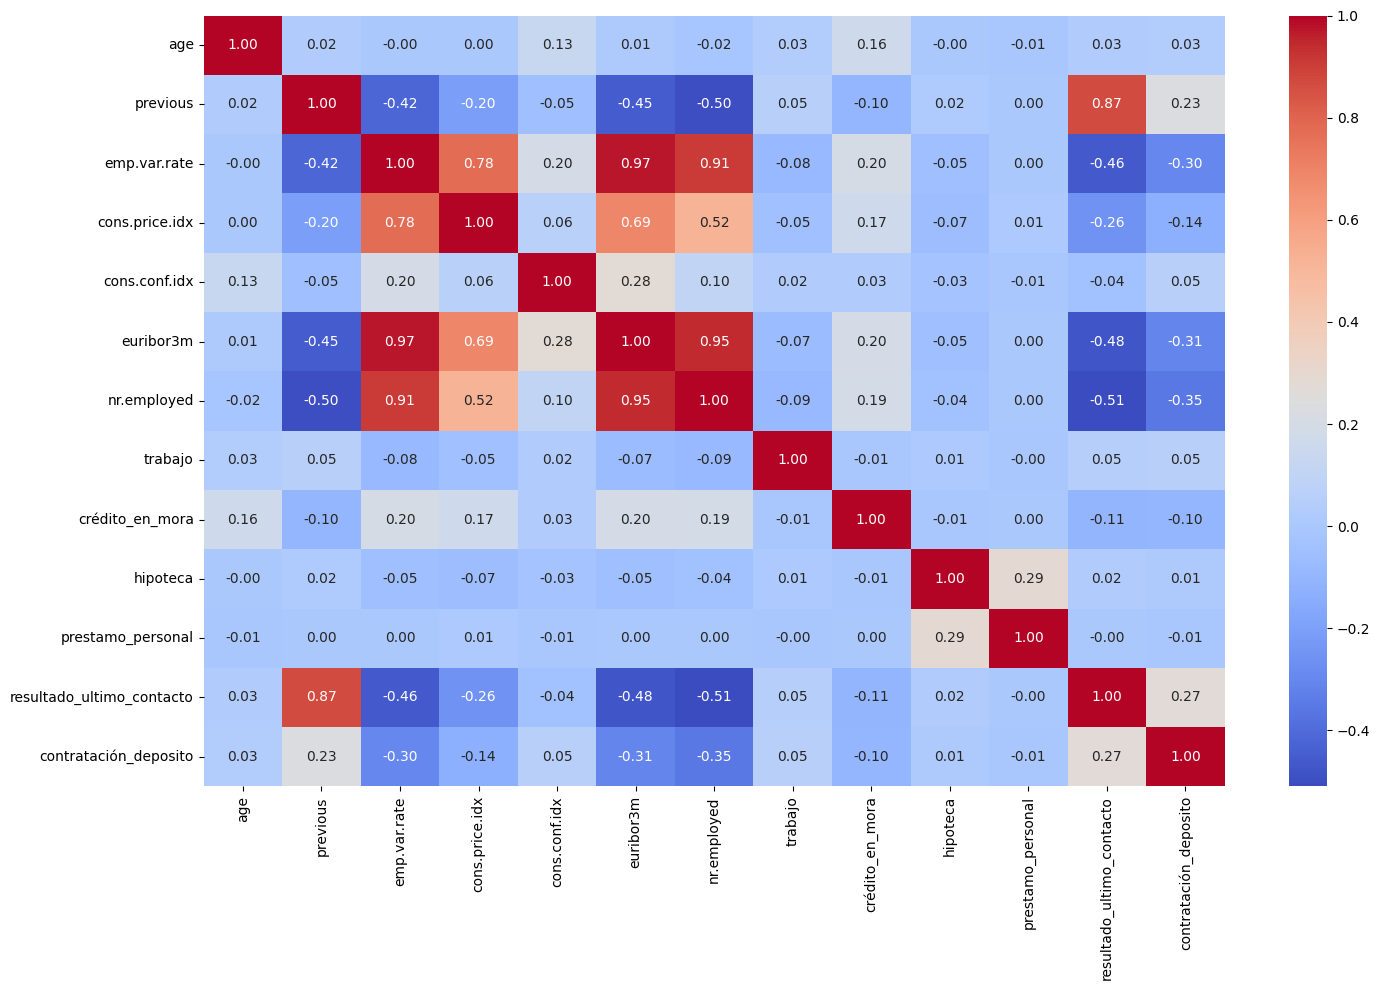

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns


dt["trabajo"] = pd.factorize(dt["job"])[0]
dt["crédito_en_mora"] = pd.factorize(dt["default"])[0]
dt["hipoteca"] = pd.factorize(dt["housing"])[0]
dt["prestamo_personal"] = pd.factorize(dt["loan"])[0]
dt["resultado_ultimo_contacto"] = pd.factorize(dt["poutcome"])[0]
dt["contratación_deposito"] = pd.factorize(dt["y"])[0]  # Si contrató o no el depósito


columnas_numericas = ["age", "previous", "emp.var.rate", "cons.price.idx", 
                      "cons.conf.idx", "euribor3m", "nr.employed"]

fig, axes = plt.subplots(figsize=(15, 10))

sns.heatmap(dt[columnas_numericas + ["trabajo", "crédito_en_mora", "hipoteca", "prestamo_personal", "resultado_ultimo_contacto", "contratación_deposito"]].corr(), 
            annot=True, fmt=".2f", cmap="coolwarm")

plt.tight_layout()
plt.show()


Puedo observar una relación con la variable contratación de depósito con número de contactos realizados durante la campaña anterior (previous), tasa de variación del empleo(emp.var.rate), tasa EURIBOR 3, número de empleados y resultados del último contacto. 

In [185]:
dt.describe()

,age,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,trabajo,crédito_en_mora,hipoteca,prestamo_personal,resultado_ultimo_contacto,contratación_deposito
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,3.673863,0.208908,0.571959,0.199825,0.169953,0.112663
std,10.42068,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,2.454340,0.406713,0.541216,0.456055,0.455811,0.316184
min,17.00000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.00000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,47.00000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,98.00000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,11.000000,2.000000,2.000000,2.000000,2.000000,1.000000


Outlier Edad


In [186]:
edad_estadistica = dt['age'].describe()
edad_estadistica

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

In [187]:
edad_iqr = edad_estadistica["75%"] - edad_estadistica["25%"]


limite_superior = edad_estadistica["75%"] + 1.5 * edad_iqr
limite_inferior = edad_estadistica["25%"] - 1.5 * edad_iqr

print(f"Límites para detectar outliers en 'age':")
print(f"  - Límite superior: {round(limite_superior, 2)}")
print(f"  - Límite inferior: {round(limite_inferior, 2)}")
print(f"  - IQR: {round(edad_iqr, 2)}")

Límites para detectar outliers en 'age':
  - Límite superior: 69.5
  - Límite inferior: 9.5
  - IQR: 15.0


In [188]:
dt_clean = dt[(dt["age"] >= 18) & (dt["age"] <= 50)]

print(f"Filas tras filtrar por edad  {dt_clean.shape[0]}")

# Me gusto mas las edades de 18 a 50 años 

Filas tras filtrar por edad  33993


In [189]:
print(f"Edad mínima: {dt_clean['age'].min()}")
print(f"Edad máxima: {dt_clean['age'].max()}")


Edad mínima: 18
Edad máxima: 50


In [190]:
edad_estadistica = dt_clean['age'].describe()
edad_estadistica

count    33993.000000
mean        36.456918
std          7.037206
min         18.000000
25%         31.000000
50%         36.000000
75%         42.000000
max         50.000000
Name: age, dtype: float64

Outlier previous

In [191]:
previous_estadistica = dt["previous"].describe()
previous_estadistica

count    41176.000000
mean         0.173013
std          0.494964
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

In [192]:
previous_iqr = previous_estadistica["75%"] - previous_estadistica["25%"]


limite_superior_previous = previous_estadistica["75%"] + 1.5 * previous_iqr
limite_inferior_previous = previous_estadistica["25%"] - 1.5 * previous_iqr


print(f"Límites para detectar outliers en 'previous':")
print(f"  - Límite superior: {round(limite_superior_previous, 2)}")
print(f"  - Límite inferior: {round(limite_inferior_previous, 2)}")
print(f"  - IQR: {round(previous_iqr, 2)}")

Límites para detectar outliers en 'previous':
  - Límite superior: 0.0
  - Límite inferior: 0.0
  - IQR: 0.0


In [193]:

dt_clean = dt_clean[(dt_clean["previous"] >= limite_inferior_previous) & (dt_clean["previous"] <= limite_superior_previous)]


print(f"Filas después de limpiar outliers en 'previous': {dt_clean.shape[0]}")


Filas después de limpiar outliers en 'previous': 29507


In [194]:
previous_estadistica = dt_clean["previous"].describe()
previous_estadistica

count    29507.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: previous, dtype: float64

outliers emp.var.rate (tasa de variación del empleo)

In [195]:
emp_var_rate_estadistica = dt["emp.var.rate"].describe()
emp_var_rate_estadistica

count    41176.000000
mean         0.081922
std          1.570883
min         -3.400000
25%         -1.800000
50%          1.100000
75%          1.400000
max          1.400000
Name: emp.var.rate, dtype: float64

In [196]:
emp_var_rate_estadisticas = dt["emp.var.rate"].describe()
emp_var_rate_iqr = emp_var_rate_estadisticas["75%"] - emp_var_rate_estadisticas["25%"]

emp_var_rate_limite_superior = emp_var_rate_estadisticas["75%"] + 1.5 * emp_var_rate_iqr
emp_var_rate_limite_inferior = emp_var_rate_estadisticas["25%"] - 1.5 * emp_var_rate_iqr

print(f"Límite superior: {emp_var_rate_limite_superior}")
print(f"Límite inferior: {emp_var_rate_limite_inferior}")

dt_clean = dt[(dt["emp.var.rate"] >= emp_var_rate_limite_inferior) & 
              (dt["emp.var.rate"] <= emp_var_rate_limite_superior)]

print(f"Filas originales: {dt.shape[0]}")
print(f"Filas tras eliminar outliers en 'emp.var.rate': {dt_clean.shape[0]}")


Límite superior: 6.200000000000001
Límite inferior: -6.6000000000000005
Filas originales: 41176
Filas tras eliminar outliers en 'emp.var.rate': 41176


outliers de la variable euribor3m (la tasa EURIBOR a 3 meses)

In [197]:
euribor_estadistica = dt["euribor3m"].describe()
euribor_estadistica


count    41176.000000
mean         3.621293
std          1.734437
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64

In [198]:
euribor_iqr = euribor_estadistica["75%"] - euribor_estadistica["25%"]


limite_superior = euribor_estadistica["75%"] + 1.5 * euribor_iqr
limite_inferior = euribor_estadistica["25%"] - 1.5 * euribor_iqr


print(f"Límites para detectar outliers en 'euribor3m':")
print(f"  - Límite superior: {round(limite_superior, 2)}")
print(f"  - Límite inferior: {round(limite_inferior, 2)}")
print(f"  - IQR: {round(euribor_iqr, 2)}")

Límites para detectar outliers en 'euribor3m':
  - Límite superior: 10.39
  - Límite inferior: -4.08
  - IQR: 3.62


In [199]:
dt_clean = dt[(dt["euribor3m"] >= limite_inferior) & (dt["euribor3m"] <= limite_superior)]


print(f"Filas originales: {dt.shape[0]}")
print(f"Filas tras eliminar outliers: {dt_clean.shape[0]}")

Filas originales: 41176
Filas tras eliminar outliers: 41176


Valores faltanes 

In [200]:
dt.isnull().sum().sort_values(ascending=False)

age                          0
job                          0
default                      0
housing                      0
loan                         0
previous                     0
poutcome                     0
emp.var.rate                 0
cons.price.idx               0
cons.conf.idx                0
euribor3m                    0
nr.employed                  0
y                            0
trabajo                      0
crédito_en_mora              0
hipoteca                     0
prestamo_personal            0
resultado_ultimo_contacto    0
contratación_deposito        0
dtype: int64

Escalado de funciones

In [201]:
from sklearn.preprocessing import MinMaxScaler

num_variables = ["age", "previous", "emp.var.rate", "euribor3m", "nr.employed"]

scaler = MinMaxScaler()

scal_features = scaler.fit_transform(dt[num_variables])

df_scal = pd.DataFrame(scal_features, index=dt.index, columns=num_variables)

df_scal["y"] = dt["y"]

df_scal.head()


,age,previous,emp.var.rate,euribor3m,nr.employed,y
0,0.481481,0.0,0.9375,0.957379,0.859735,no
1,0.493827,0.0,0.9375,0.957379,0.859735,no
2,0.246914,0.0,0.9375,0.957379,0.859735,no
3,0.283951,0.0,0.9375,0.957379,0.859735,no
4,0.481481,0.0,0.9375,0.957379,0.859735,no


Codificación de Variables Categóricas

In [202]:
dt = pd.get_dummies(dt, columns=["poutcome"], prefix="poutcome", drop_first=True)

dt.filter(like="poutcome").head()


,poutcome_nonexistent,poutcome_success
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


In [203]:
dt['loan'] = dt['loan'].map({'yes': 1, 'no': 0})


In [204]:
dt["housing"] = pd.factorize(dt["housing"])[0]
dt["loan"] = pd.factorize(dt["loan"])[0]

print(dt[["housing", "loan"]].head())


   housing  loan
0        0     0
1        0     0
2        1     0
3        0     0
4        0     1


In [205]:
print(dt[["poutcome_nonexistent", "poutcome_success"]].value_counts())
print(dt["housing"].value_counts())
print(dt["loan"].value_counts())


poutcome_nonexistent  poutcome_success
True                  False               35551
False                 False                4252
                      True                 1373
Name: count, dtype: int64
housing
1    21571
0    18615
2      990
Name: count, dtype: int64
loan
 0    33938
 1     6248
-1      990
Name: count, dtype: int64


In [206]:
loan_moda = dt["loan"].mode()[0]
dt["loan"] = dt["loan"].replace(-1, loan_moda)
print(dt["loan"].value_counts())



loan
0    34928
1     6248
Name: count, dtype: int64


In [207]:
# Reemplazar el valor 2 con la moda de la columna housing
housing_moda = dt["housing"].mode()[0]
dt["housing"] = dt["housing"].replace(2, housing_moda)
print(dt["housing"].value_counts())



housing
1    22561
0    18615
Name: count, dtype: int64


In [208]:
from sklearn.preprocessing import MinMaxScaler

# Aplicamos MinMaxScaler para asegurarnos de que todas las características sean no negativas
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Selección de características utilizando Chi-cuadrado
selector = SelectKBest(chi2, k=10)  # Seleccionamos las 10 mejores características
X_new = selector.fit_transform(X_train, y_train)

# Mostrar las características seleccionadas
selected_features = X_encoded.columns[selector.get_support()]
print("Características seleccionadas con Chi-cuadrado:", selected_features)


NameError: name 'X_encoded' is not defined

In [ ]:
print(dt.columns)  # Verifica las columnas presentes en el DataFrame



Index(['age', 'job', 'default', 'housing', 'loan', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'trabajo', 'crédito_en_mora', 'hipoteca', 'prestamo_personal',
       'resultado_ultimo_contacto', 'contratación_deposito',
       'poutcome_nonexistent', 'poutcome_success'],
      dtype='object')


In [ ]:
# Eliminar columnas innecesarias
dt.drop(columns=["job"], inplace=True)  


print(dt.head())


   age  default  housing  loan  previous  emp.var.rate  cons.price.idx  \
0   56       no        0     0         0           1.1          93.994   
1   57  unknown        0     0         0           1.1          93.994   
2   37       no        1     0         0           1.1          93.994   
3   40       no        0     0         0           1.1          93.994   
4   56       no        0     1         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed   y  trabajo  crédito_en_mora  \
0          -36.4      4.857       5191.0  no        0                0   
1          -36.4      4.857       5191.0  no        1                1   
2          -36.4      4.857       5191.0  no        1                0   
3          -36.4      4.857       5191.0  no        2                0   
4          -36.4      4.857       5191.0  no        1                0   

   hipoteca  prestamo_personal  resultado_ultimo_contacto  \
0         0                  0                   

Selección de características

In [ ]:
from sklearn.preprocessing import LabelEncoder


categorical_columns = ['default', 'housing', 'loan', 'poutcome_nonexistent', 'poutcome_success']

# Usamos LabelEncoder para convertir las categorías a números
label_encoder = LabelEncoder()
for col in categorical_columns:
    dt[col] = label_encoder.fit_transform(dt[col])

# Verifica las primeras filas después de la codificación
print(dt.head())


   age  default  housing  loan  previous  emp.var.rate  cons.price.idx  \
0   56        0        0     0         0           1.1          93.994   
1   57        1        0     0         0           1.1          93.994   
2   37        0        1     0         0           1.1          93.994   
3   40        0        0     0         0           1.1          93.994   
4   56        0        0     1         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed   y  trabajo  crédito_en_mora  \
0          -36.4      4.857       5191.0  no        0                0   
1          -36.4      4.857       5191.0  no        1                1   
2          -36.4      4.857       5191.0  no        1                0   
3          -36.4      4.857       5191.0  no        2                0   
4          -36.4      4.857       5191.0  no        1                0   

   hipoteca  prestamo_personal  resultado_ultimo_contacto  \
0         0                  0                   

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif


selector = SelectKBest(f_classif, k=10)  # Seleccionamos las 10 mejores características
X_new = selector.fit_transform(X, y)

# Mostrar las características seleccionadas
selected_features = X.columns[selector.get_support()]
print("Características seleccionadas:", selected_features)


Características seleccionadas: Index(['previous', 'emp.var.rate', 'cons.price.idx', 'euribor3m',
       'nr.employed', 'crédito_en_mora', 'resultado_ultimo_contacto',
       'contratación_deposito', 'poutcome_nonexistent', 'poutcome_success'],
      dtype='object')


/home/vscode/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [ ]:
print(X.var())  # Ver la varianza de cada característica


age                           108.590569
default                         0.165415
housing                         0.247710
loan                            0.128717
previous                        0.244990
emp.var.rate                    2.467672
cons.price.idx                  0.335055
cons.conf.idx                  21.417088
euribor3m                       3.008272
nr.employed                  5220.259596
trabajo                         6.023784
crédito_en_mora                 0.165415
hipoteca                        0.292915
prestamo_personal               0.207986
resultado_ultimo_contacto       0.207764
contratación_deposito           0.099972
poutcome_nonexistent            0.117950
poutcome_success                0.032234
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Asegurémonos de que 'X' y 'y' están definidos correctamente
# Aquí asumimos que 'X' es tu conjunto de características y 'y' la variable objetivo

# Selección de las características que elegimos previamente
X = dt[['previous', 'emp.var.rate', 'cons.price.idx', 'euribor3m', 
        'nr.employed', 'crédito_en_mora', 'resultado_ultimo_contacto', 
        'contratación_deposito', 'poutcome_nonexistent', 'poutcome_success']]
y = dt['y']  # O la columna que contiene la variable objetivo

# Dividir los datos en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model = LogisticRegression(max_iter=1000)  # Asegurándonos de que el modelo converja
model.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 1.0
Confusion Matrix:
 [[7265    0]
 [   0  971]]
Classification Report:
               precision    recall  f1-score   support

          no       1.00      1.00      1.00      7265
         yes       1.00      1.00      1.00       971

    accuracy                           1.00      8236
   macro avg       1.00      1.00      1.00      8236
weighted avg       1.00      1.00      1.00      8236



In [ ]:
# Copiamos dt para no modificar el original
dt_temp = dt[['previous', 'emp.var.rate', 'cons.price.idx', 'euribor3m', 
              'nr.employed', 'crédito_en_mora', 'resultado_ultimo_contacto', 
              'contratación_deposito', 'poutcome_nonexistent', 'poutcome_success', 'y']].copy()

# Codificamos 'y' como 0/1
dt_temp['y'] = dt_temp['y'].map({'no': 0, 'yes': 1})

# Calculamos la correlación
correlation_matrix = dt_temp.corr()

# Mostramos la correlación de cada variable con 'y'
print(correlation_matrix['y'].sort_values(ascending=False))


y                            1.000000
contratación_deposito        1.000000
poutcome_success             0.316302
resultado_ultimo_contacto    0.270399
previous                     0.230202
crédito_en_mora             -0.099364
cons.price.idx              -0.136134
poutcome_nonexistent        -0.193522
emp.var.rate                -0.298289
euribor3m                   -0.307740
nr.employed                 -0.354669
Name: y, dtype: float64


In [210]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Redefinimos las variables X y y SIN 'contratación_deposito' me dio 1 con respecto y
X = dt[['previous', 'emp.var.rate', 'cons.price.idx', 'euribor3m', 
        'nr.employed', 'crédito_en_mora', 'resultado_ultimo_contacto', 
        'poutcome_nonexistent', 'poutcome_success']]  # <--- sin contratación_deposito
y = dt['y']

# Repetimos la división entre entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Volvemos a entrenar el modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predicción del modelo
y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8937591063623118
Confusion Matrix:
 [[7208   57]
 [ 818  153]]
Classification Report:
               precision    recall  f1-score   support

          no       0.90      0.99      0.94      7265
         yes       0.73      0.16      0.26       971

    accuracy                           0.89      8236
   macro avg       0.81      0.57      0.60      8236
weighted avg       0.88      0.89      0.86      8236



Son pocos los clientes que contraten un depósito a largo plazo 